# 6 — Sensor Scaling and ESN Dynamics Diagnostics

This notebook investigates why the absolute Primary and Secondary responses look nearly flat and shows a scientifically safer visualization. It does **not** optimize hyperparameters or report new regression performance.

The recommended separation is:

- **For presentation:** show change from the first post-contact sample in micro-units.
- **For the ESN:** retain leakage-safe `StandardScaler` scaling fitted only on the training materials.

The combined diagnostic follows the causal sequence:

**raw sensors → baseline-centered response → five scaled ESN inputs → reservoir dynamics**.


# 1. Imports and saved ESN configuration

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler

TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
PARAMETER_TARGET = "eff"
VISUALIZATION_SEED = 42

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")

DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
PARAMETER_FILE = RESULTS_DIR / "30C-40C-50C-60C_eff_v6_unified_parameters.json"
if not PARAMETER_FILE.is_file():
    raise FileNotFoundError(f"Missing {PARAMETER_FILE}. Run Notebook 4AA first.")

with PARAMETER_FILE.open() as file:
    SAVED_CONFIGURATION = json.load(file)

ANALYSIS_WINDOW = tuple(SAVED_CONFIGURATION["analysis_window"])
ESN_PARAMETERS = SAVED_CONFIGURATION["esn_parameters"]
ESN_RES_SIZE = int(ESN_PARAMETERS["res_size"])
ESN_LEAK_RATE = float(ESN_PARAMETERS["leak_rate"])
ESN_INPUT_MAGNITUDE = float(ESN_PARAMETERS["input_magnitude"])
ESN_SPECTRAL_RADIUS = float(ESN_PARAMETERS["spectral_radius"])
ESN_WASHOUT = int(ESN_PARAMETERS["washout"])

print("Loaded configuration:", PARAMETER_FILE)
print("Analysis window:", ANALYSIS_WINDOW)
print("ESN parameters:", ESN_PARAMETERS)


Loaded configuration: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_v6_unified_parameters.json
Analysis window: (0.0, 5.0)
ESN parameters: {'res_size': 25, 'leak_rate': 0.26086084827572703, 'input_magnitude': 1.0889887240721112, 'spectral_radius': 1.4454615868954506, 'washout': 3}


# 2. Load the four-temperature dataset

In [2]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
load_rows = []

for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            warnings.warn(
                f"Skipping {temperature}/{path.name}; missing {sorted(missing)}"
            )
            continue
        frame["Temperature"] = temperature
        frame["source_file"] = path.name
        frames.append(frame)
        load_rows.append({
            "Temperature": temperature,
            "file": path.name,
            "rows_loaded": len(frame),
        })

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
DATA["Temperature_C"] = pd.to_numeric(
    DATA["Temperature"].str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
if DATA["Temperature_C"].isna().any():
    raise ValueError("A temperature-folder name could not be converted to Celsius.")

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Ignore processed-file property cells and apply one standard table everywhere.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

# Temperature is required in the ID because material/trial numbers repeat by folder.
DATA["trial_id"] = (
    DATA["Temperature"].astype(str)
    + "__" + DATA["Sample"].astype(str)
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["Temperature", "trial_id", "Time"]).reset_index(drop=True)

summary = (
    DATA.groupby(["trial_id", "Temperature", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
temperature_summary = (
    summary.groupby("Temperature", as_index=False)
    .agg(
        trials=("trial_id", "nunique"),
        materials=("Sample", "nunique"),
        minimum_timesteps=("n_timesteps", "min"),
        maximum_timesteps=("n_timesteps", "max"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Unique temperature-specific trials: {DATA['trial_id'].nunique()}")
display(temperature_summary)


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 70,480
Unique temperature-specific trials: 336


,Temperature,trials,materials,minimum_timesteps,maximum_timesteps
0,30C,84,14,184,227
1,40C,84,14,200,362
2,50C,84,14,183,404
3,60C,84,14,186,326


# 3. Detect contact and retain the 0–5 s post-contact window

In [3]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


In [4]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())


Aligned trials retained: 336


,trial_id,Temperature,Temperature_C,Sample,Trial,contact_time,n_analysis_samples
0,30C__aluminum_trial_1,30C,30.0,aluminum,1,8.40066,50
1,30C__aluminum_trial_2,30C,30.0,aluminum,2,7.40070,50
2,30C__aluminum_trial_3,30C,30.0,aluminum,3,7.70070,51
3,30C__aluminum_trial_4,30C,30.0,aluminum,4,8.70070,51
4,30C__aluminum_trial_5,30C,30.0,aluminum,5,7.20070,51


# 4. Define the two distinct scaling operations

`baseline_centered_micro` is used only to make small physical sensor changes visible:

\[
\Delta x_\mu(t)=10^6[x(t)-x(t_0)].
\]

`StandardScaler` is the transformation used before the ESN. In this notebook, the selected material is treated as held out: the scaler is fitted using every other material and then applied to the selected trial.


In [5]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def baseline_centered_micro(values):
    values = np.asarray(values, float)
    return (values - values[0]) * 1e6


def relative_percent_change(values):
    values = np.asarray(values, float)
    baseline = values[0]
    if np.isclose(baseline, 0.0):
        return np.full_like(values, np.nan)
    return 100.0 * (values - baseline) / abs(baseline)


INPUT_NAMES = (
    "Smoothed Primary",
    "Smoothed Secondary",
    "Primary − Secondary",
    "dPrimary/dt",
    "dSecondary/dt",
)


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def fit_lomo_style_input_scaler(held_out_material):
    training_sequences = [
        raw_esn_input(trial)
        for trial in aligned_trials.values()
        if trial["Sample"].iloc[0] != held_out_material
    ]
    if not training_sequences:
        raise ValueError("No training trials remain after holding out the material.")
    return StandardScaler().fit(np.vstack(training_sequences))


# 5. Select a representative trial

Change these three values to inspect another trial. The scaler will automatically exclude the selected material when it is fitted.


In [6]:
SELECTED_TEMPERATURE = "30C"
SELECTED_MATERIAL = "aluminum"
SELECTED_REPETITION = 1

SELECTED_TRIAL_ID = (
    f"{SELECTED_TEMPERATURE}__{SELECTED_MATERIAL}_trial_{SELECTED_REPETITION}"
)
if SELECTED_TRIAL_ID not in aligned_trials:
    available = [x for x in aligned_trials if SELECTED_MATERIAL in x][:10]
    raise KeyError(f"{SELECTED_TRIAL_ID} was not retained. Examples: {available}")

selected_trial = aligned_trials[SELECTED_TRIAL_ID]
selected_time = selected_trial["time_from_contact"].to_numpy(float)
selected_primary = _smooth(selected_trial["Primary"].to_numpy(float))
selected_secondary = _smooth(selected_trial["Secondary"].to_numpy(float))

input_scaler = fit_lomo_style_input_scaler(SELECTED_MATERIAL)
unscaled_five_inputs = raw_esn_input(selected_trial)
scaled_five_inputs = input_scaler.transform(unscaled_five_inputs)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Held-out material for scaler fitting:", SELECTED_MATERIAL)
print("Samples in trial:", len(selected_trial))


Selected trial: 30C__aluminum_trial_1
Held-out material for scaler fitting: aluminum
Samples in trial: 50


# 6. Why the original graph looks flat

The left graph shows the absolute readings. The center graph removes each sensor's starting offset while preserving its physical change. The right graph shows percentage change for reference; it is not recommended as the primary display when comparing amplitudes across trials.


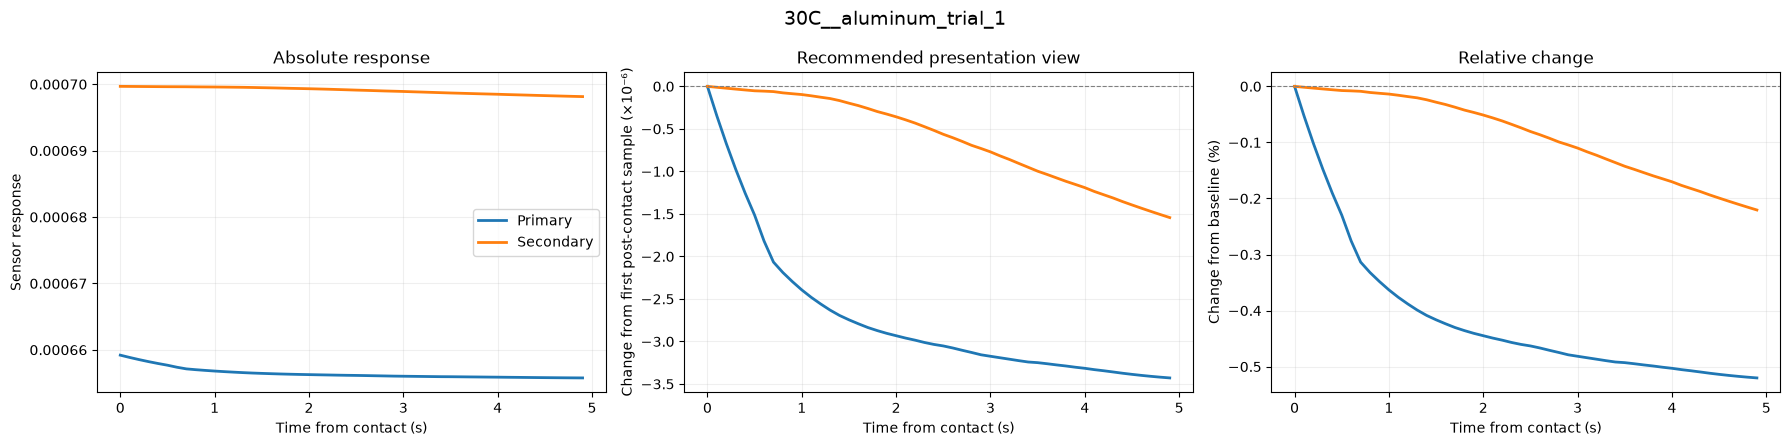

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)

axes[0].plot(selected_time, selected_primary, label="Primary", linewidth=2)
axes[0].plot(selected_time, selected_secondary, label="Secondary", linewidth=2)
axes[0].set(title="Absolute response", ylabel="Sensor response")

axes[1].plot(selected_time, baseline_centered_micro(selected_primary), label="Primary", linewidth=2)
axes[1].plot(selected_time, baseline_centered_micro(selected_secondary), label="Secondary", linewidth=2)
axes[1].axhline(0, color="0.5", linewidth=0.8, linestyle="--")
axes[1].set(title="Recommended presentation view", ylabel="Change from first post-contact sample (×10⁻⁶)")

axes[2].plot(selected_time, relative_percent_change(selected_primary), label="Primary", linewidth=2)
axes[2].plot(selected_time, relative_percent_change(selected_secondary), label="Secondary", linewidth=2)
axes[2].axhline(0, color="0.5", linewidth=0.8, linestyle="--")
axes[2].set(title="Relative change", ylabel="Change from baseline (%)")

for ax in axes:
    ax.set_xlabel("Time from contact (s)")
    ax.grid(alpha=0.2)
axes[0].legend()
fig.suptitle(SELECTED_TRIAL_ID, fontsize=14)
plt.tight_layout()
plt.show()


# 7. The exact five standardized channels that drive the ESN

These curves are more informative for interpreting the reservoir than the absolute Primary and Secondary plot, because the reservoir receives all five standardized channels.


,channel,training_mean,training_std,selected_trial_min_z,selected_trial_max_z
0,Smoothed Primary,6.542339e-04,6.356582e-06,0.241402,0.780769
1,Smoothed Secondary,6.980299e-04,2.045091e-06,0.053067,0.807594
2,Primary − Secondary,-4.379604e-05,4.924831e-06,0.148829,0.672393
3,dPrimary/dt,-1.510866e-06,3.419994e-06,-0.574220,0.416082
4,dSecondary/dt,-6.029596e-07,7.289959e-07,0.195908,0.762519


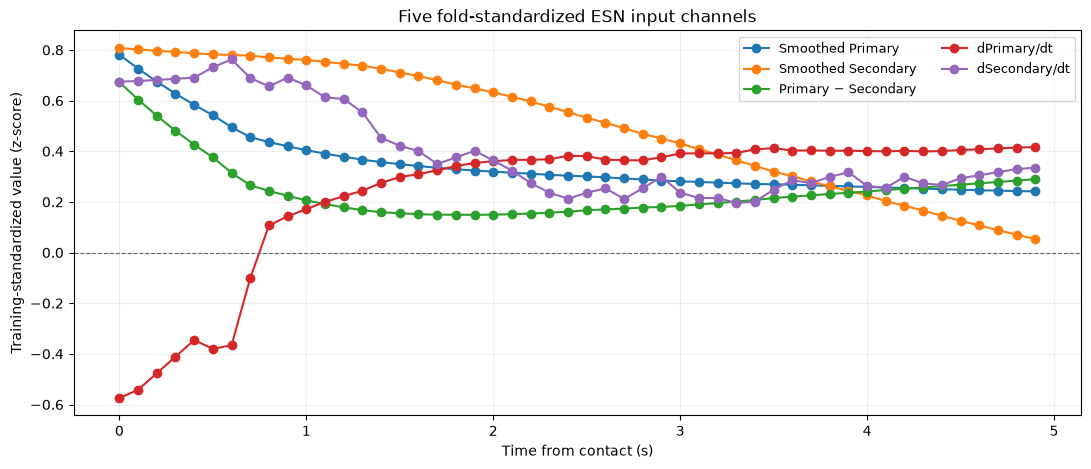

In [8]:
scaler_table = pd.DataFrame({
    "channel": INPUT_NAMES,
    "training_mean": input_scaler.mean_,
    "training_std": input_scaler.scale_,
    "selected_trial_min_z": scaled_five_inputs.min(axis=0),
    "selected_trial_max_z": scaled_five_inputs.max(axis=0),
})
display(scaler_table)

fig, ax = plt.subplots(figsize=(13, 5))
for column, name in enumerate(INPUT_NAMES):
    ax.plot(selected_time, scaled_five_inputs[:, column], marker="o", label=name)
ax.axhline(0, color="0.4", linewidth=0.8, linestyle="--")
ax.set(
    title="Five fold-standardized ESN input channels",
    xlabel="Time from contact (s)",
    ylabel="Training-standardized value (z-score)",
)
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.2)
plt.show()


# 8. Run the saved reservoir on those five scaled inputs

In [9]:
class ManualReservoir:
    def __init__(
        self, res_size, leak_rate, input_magnitude, spectral_radius,
        washout=0, random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (
            rng.random((self.res_size, 1 + 5)) - 0.5
        ) * float(input_magnitude)
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        self.W = (W / radius.real) * float(spectral_radius)

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            proposed = np.tanh(self.Win @ np.vstack((1.0, u)) + self.W @ x)
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


reservoir = ManualReservoir(
    res_size=ESN_RES_SIZE,
    leak_rate=ESN_LEAK_RATE,
    input_magnitude=ESN_INPUT_MAGNITUDE,
    spectral_radius=ESN_SPECTRAL_RADIUS,
    washout=ESN_WASHOUT,
    random_state=VISUALIZATION_SEED,
)
selected_states = reservoir.run(scaled_five_inputs)
state_time = selected_time[ESN_WASHOUT:]

print("Five-channel input matrix:", scaled_five_inputs.shape)
print("Retained reservoir-state matrix:", selected_states.shape)


Five-channel input matrix: (50, 5)
Retained reservoir-state matrix: (47, 25)


# 9. Combined input-to-dynamics diagnostic

The vertical alignment is the important part: changes in the baseline-centered sensors create changes in the five standardized inputs, which drive the reservoir states. The individual units need not copy any one sensor channel.


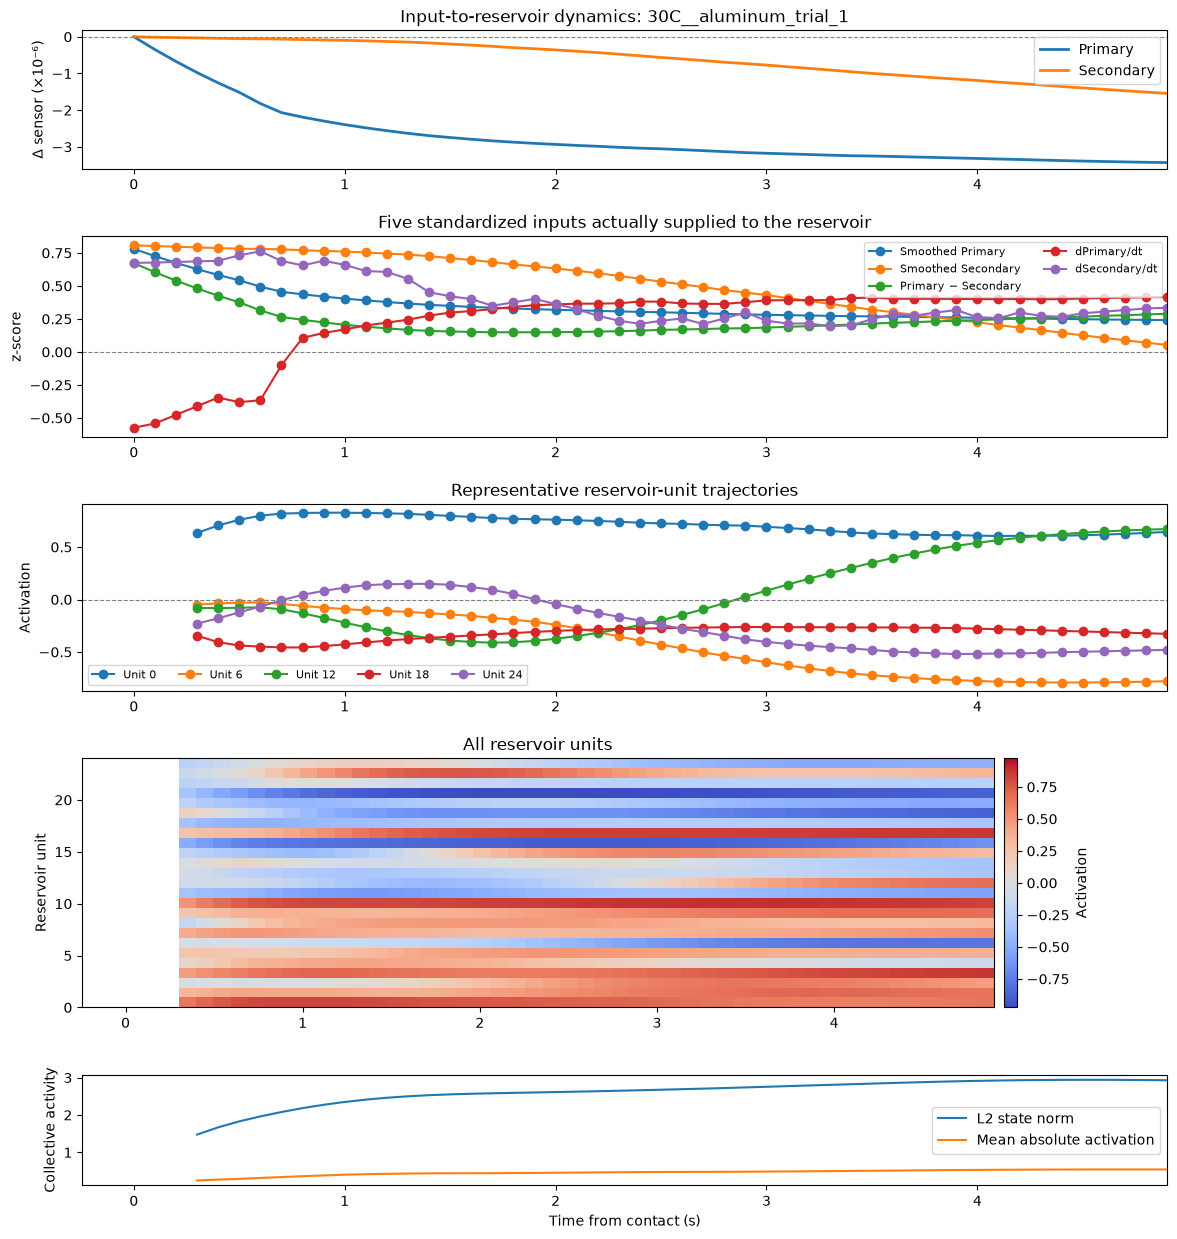

In [10]:
def representative_units(n_units, maximum=5):
    return np.unique(np.linspace(0, n_units - 1, min(maximum, n_units), dtype=int))


units = representative_units(selected_states.shape[1])
fig = plt.figure(figsize=(14, 15))
grid = fig.add_gridspec(5, 1, height_ratios=[1.0, 1.45, 1.35, 1.8, 0.8], hspace=0.38)

ax_delta = fig.add_subplot(grid[0])
ax_delta.plot(selected_time, baseline_centered_micro(selected_primary), label="Primary", linewidth=2)
ax_delta.plot(selected_time, baseline_centered_micro(selected_secondary), label="Secondary", linewidth=2)
ax_delta.axhline(0, color="0.5", linewidth=0.8, linestyle="--")
ax_delta.set(title=f"Input-to-reservoir dynamics: {SELECTED_TRIAL_ID}", ylabel="Δ sensor (×10⁻⁶)")
ax_delta.legend()

ax_five = fig.add_subplot(grid[1], sharex=ax_delta)
for column, name in enumerate(INPUT_NAMES):
    ax_five.plot(selected_time, scaled_five_inputs[:, column], marker="o", label=name)
ax_five.axhline(0, color="0.5", linewidth=0.8, linestyle="--")
ax_five.set(title="Five standardized inputs actually supplied to the reservoir", ylabel="z-score")
ax_five.legend(ncol=2, fontsize=8)

ax_states = fig.add_subplot(grid[2], sharex=ax_delta)
for unit in units:
    ax_states.plot(state_time, selected_states[:, unit], marker="o", label=f"Unit {unit}")
ax_states.axhline(0, color="0.5", linewidth=0.8, linestyle="--")
ax_states.set(title="Representative reservoir-unit trajectories", ylabel="Activation")
ax_states.legend(ncol=5, fontsize=8)

ax_heat = fig.add_subplot(grid[3], sharex=ax_delta)
limit = np.max(np.abs(selected_states))
image = ax_heat.imshow(
    selected_states.T, aspect="auto", origin="lower",
    extent=[state_time.min(), state_time.max(), 0, selected_states.shape[1] - 1],
    cmap="coolwarm", vmin=-limit, vmax=limit, interpolation="nearest",
)
ax_heat.set(title="All reservoir units", ylabel="Reservoir unit")
fig.colorbar(image, ax=ax_heat, label="Activation", pad=0.01)

ax_collective = fig.add_subplot(grid[4], sharex=ax_delta)
ax_collective.plot(state_time, np.linalg.norm(selected_states, axis=1), label="L2 state norm")
ax_collective.plot(state_time, np.mean(np.abs(selected_states), axis=1), label="Mean absolute activation")
ax_collective.set(xlabel="Time from contact (s)", ylabel="Collective activity")
ax_collective.legend()

plt.show()


# 10. Optional cross-material comparison

The function below uses baseline-centered micro-units and common axes. This preserves physically meaningful amplitude differences among materials, unlike independent per-trial z-scoring.


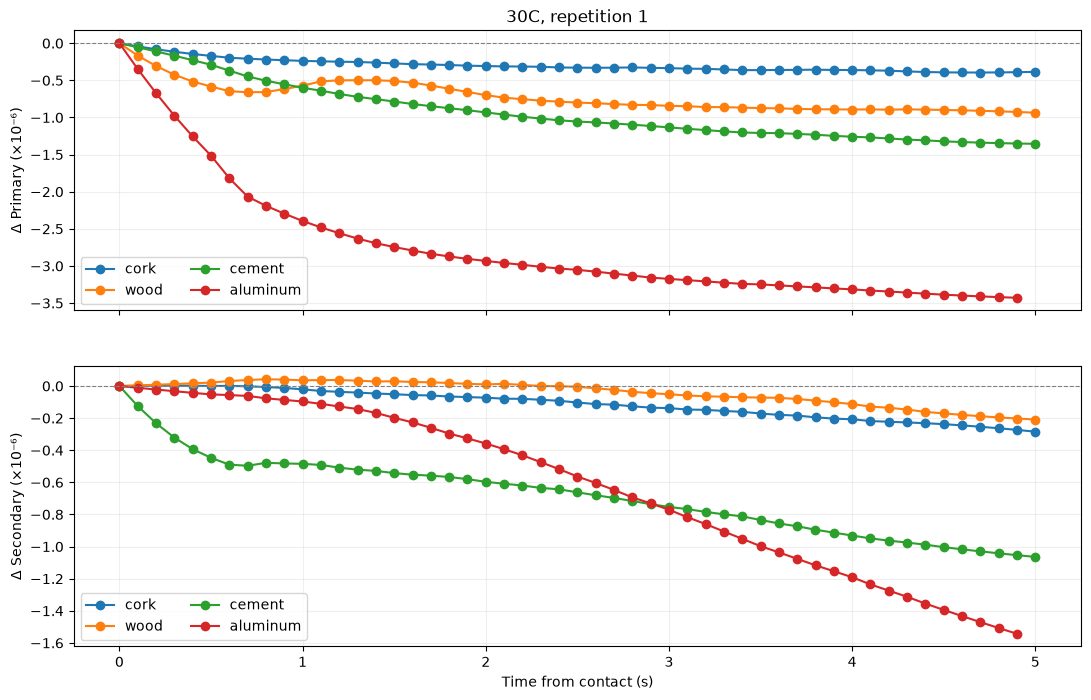

In [11]:
def compare_material_responses(
    materials=("cork", "wood", "cement", "aluminum"),
    temperature="30C", repetition=1,
):
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    for material in materials:
        trial_id = f"{temperature}__{material}_trial_{repetition}"
        if trial_id not in aligned_trials:
            warnings.warn(f"Skipping unavailable {trial_id}")
            continue
        trial = aligned_trials[trial_id]
        time = trial["time_from_contact"].to_numpy(float)
        primary = _smooth(trial["Primary"].to_numpy(float))
        secondary = _smooth(trial["Secondary"].to_numpy(float))
        axes[0].plot(time, baseline_centered_micro(primary), marker="o", label=material)
        axes[1].plot(time, baseline_centered_micro(secondary), marker="o", label=material)

    axes[0].set(title=f"{temperature}, repetition {repetition}", ylabel="Δ Primary (×10⁻⁶)")
    axes[1].set(xlabel="Time from contact (s)", ylabel="Δ Secondary (×10⁻⁶)")
    for ax in axes:
        ax.axhline(0, color="0.5", linewidth=0.8, linestyle="--")
        ax.grid(alpha=0.2)
        ax.legend(ncol=2)
    plt.show()


compare_material_responses()


# Interpretation

- The absolute plot answers: **What were the sensor readings?**
- The baseline-centered plot answers: **How much did each sensor change after contact?**
- The standardized five-channel plot answers: **What numerical signals entered the ESN?**
- The state trajectories and heatmap answer: **How did the reservoir transform those inputs over time?**

Baseline centering is a display choice. The leakage-safe `StandardScaler` remains the model-input transformation. This notebook deliberately does not change the trained workflow or claim that a prettier plot improves regression performance.
